In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from evaluation.portfolio import portfolio_roi, portfolio_kelly, portfolio_breakdown

abt = pd.read_parquet('C:/Users/twluc/frame/01_data/03_abt/abt.parquet')
ts = pd.read_parquet('C:/Users/twluc/frame/01_data/02_features/team_season.parquet')
final = pd.read_parquet('C:/Users/twluc/frame/01_data/02_features/team_season_final.parquet')
thr = json.load(open('C:/Users/twluc/frame/01_data/02_features/thresholds.json'))

In [12]:
def plot_impl_groups(data, group_col):

    d = data[['mrkt_home_away_impl_diff','mrkt_home_impl','mrkt_draw_impl','mrkt_away_impl','t_result', group_col]].dropna().copy()

    order = d[group_col].value_counts().index.tolist()

    plt.figure(figsize=(13, 6))
    total = len(d)

    for grp_val in order:
        grp = d[d[group_col] == grp_val]
        pct = len(grp) / total * 100
        plt.scatter(grp['mrkt_home_away_impl_diff'], grp['mrkt_draw_impl'],
                    label=f'{grp_val} ({pct:.1f}%)',
                    alpha=0.3, s=8)

    plt.xlim(1, -1)
    plt.ylim(0,0.4)
    plt.axvline(0, color='black', linewidth=0.8, linestyle='--')

    plt.xlabel('home / away implied probability advantage')
    plt.ylabel('draw implied probability')

    plt.legend(markerscale=3, fontsize=8)
    plt.tight_layout()
    plt.show()

    for grp_val in order:
        grp = d[d[group_col] == grp_val]
        sub = grp['t_result'].value_counts(normalize=True)
        print(f'{len(grp):4d} {str(grp_val):20s} '
              f'H: {sub.get("H", 0):5.1%} ({portfolio_roi(grp["mrkt_home_impl"], (grp["t_result"]=="H").astype(int))["roi"]:+6.1%})  '
              f'D: {sub.get("D", 0):5.1%} ({portfolio_roi(grp["mrkt_draw_impl"], (grp["t_result"]=="D").astype(int))["roi"]:+6.1%})  '
              f'A: {sub.get("A", 0):5.1%} ({portfolio_roi(grp["mrkt_away_impl"], (grp["t_result"]=="A").astype(int))["roi"]:+6.1%})')



In [13]:
from sklearn.cluster import KMeans

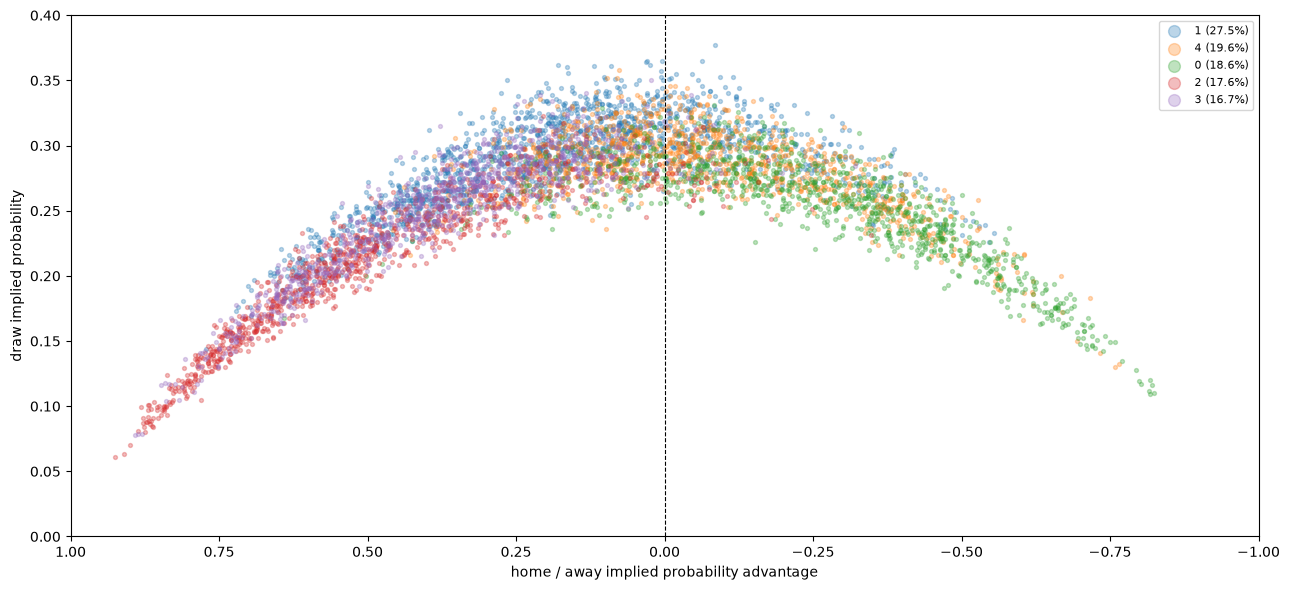

1525 1                    H: 44.7% ( -3.8%)  D: 26.2% ( -9.1%)  A: 29.2% ( -2.7%)
1086 4                    H: 29.1% (-16.6%)  D: 29.7% ( +5.1%)  A: 41.2% ( -1.5%)
1030 0                    H: 26.8% ( -3.0%)  D: 22.5% (-10.9%)  A: 50.7% ( -2.6%)
 974 2                    H: 66.6% ( -0.2%)  D: 17.4% (-16.8%)  A: 16.0% ( -7.7%)
 922 3                    H: 55.0% ( -6.4%)  D: 28.2% (+13.1%)  A: 16.8% (-21.1%)


In [35]:
sub = abt[abt['homet_game_number'] > 8].copy()

sub['mrkt_home_away_impl_diff'] = sub['mrkt_home_impl'] - sub['mrkt_away_impl']

features = ['homet_season_goals_for_avg', 'homet_season_goals_agst_avg',
            'awayt_season_goals_for_avg', 'awayt_season_goals_agst_avg']

km = KMeans(n_clusters=5, random_state=0)
sub['matchup_km'] = km.fit_predict(sub[features].dropna()).astype(str)

plot_impl_groups(sub, 'matchup_km')


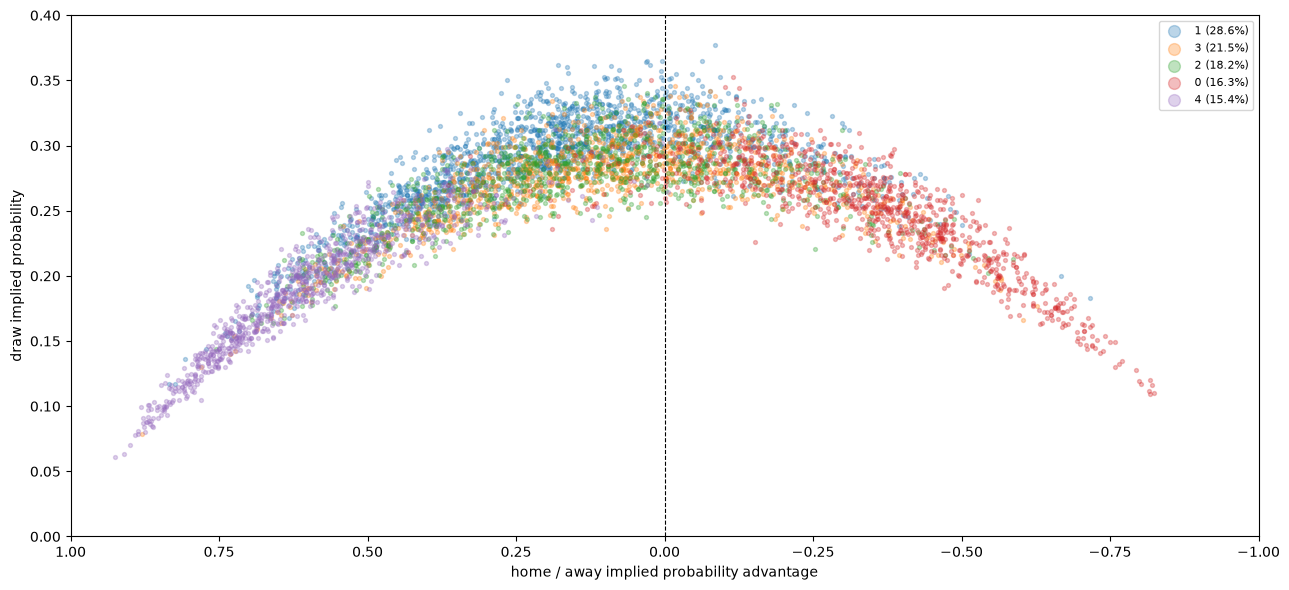

1583 1                    H: 43.0% ( -9.1%)  D: 29.1% ( +1.1%)  A: 27.9% ( -4.4%)
1188 3                    H: 38.6% (-11.9%)  D: 28.4% ( +4.3%)  A: 33.0% ( -2.4%)
1008 2                    H: 48.7% ( +5.7%)  D: 21.7% (-19.7%)  A: 29.6% ( -7.3%)
 903 0                    H: 20.0% (-13.0%)  D: 24.1% ( -2.9%)  A: 55.8% ( -2.2%)
 855 4                    H: 72.2% ( -0.5%)  D: 17.3% ( -9.4%)  A: 10.5% (-20.6%)


In [38]:
sub = abt[abt['homet_game_number'] > 8].copy()

sub['mrkt_home_away_impl_diff'] = sub['mrkt_home_impl'] - sub['mrkt_away_impl']

features = ['homet_season_shots_on_target_for_avg', 'homet_season_shots_on_target_agst_avg',
            'awayt_season_shots_on_target_for_avg', 'awayt_season_shots_on_target_agst_avg']

km = KMeans(n_clusters=5, random_state=0)
sub['matchup_km'] = km.fit_predict(sub[features].dropna()).astype(str)

plot_impl_groups(sub, 'matchup_km')


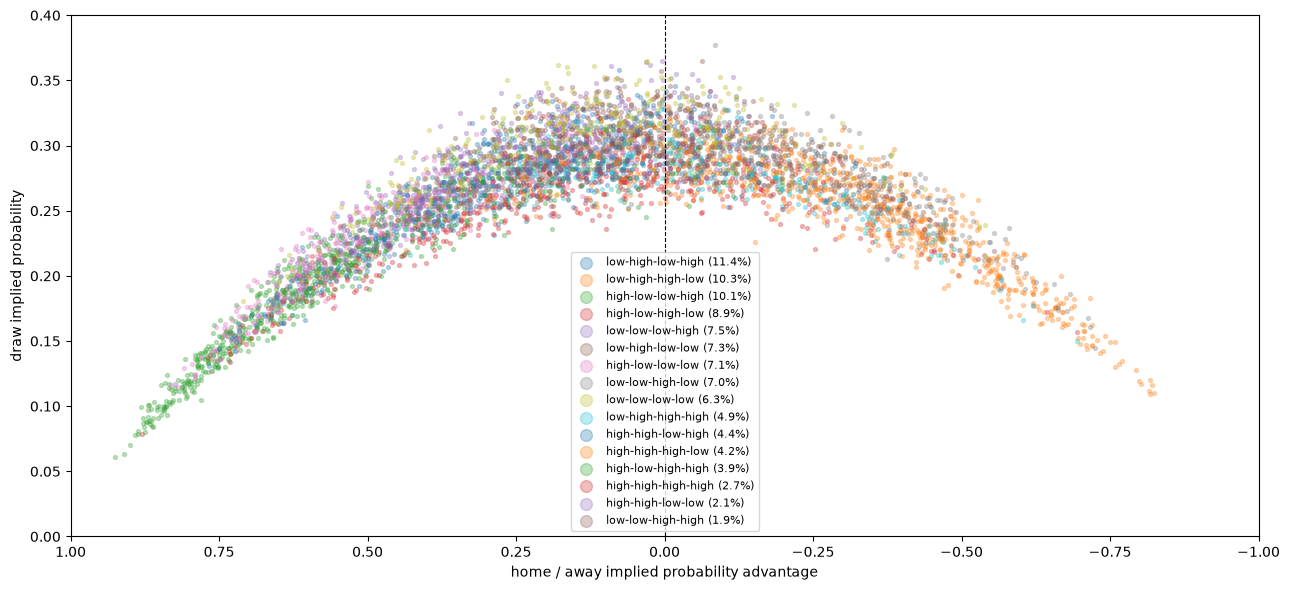

 629 low-high-low-high    H: 40.7% (-10.3%)  D: 29.6% ( +2.8%)  A: 29.7% ( -4.0%)
 572 low-high-high-low    H: 21.3% ( -6.7%)  D: 22.2% (-11.1%)  A: 56.5% ( -1.4%)
 558 high-low-low-high    H: 67.6% ( -6.6%)  D: 21.0% ( +7.7%)  A: 11.5% (-13.7%)
 493 high-low-high-low    H: 48.5% ( +3.5%)  D: 20.9% (-20.0%)  A: 30.6% ( -4.4%)
 414 low-low-low-high     H: 51.4% ( -3.9%)  D: 26.8% ( -4.0%)  A: 21.7% ( -7.9%)
 405 low-high-low-low     H: 35.8% ( -2.7%)  D: 27.9% ( -8.0%)  A: 36.3% ( -4.4%)
 395 high-low-low-low     H: 64.1% ( +0.7%)  D: 22.3% ( -5.2%)  A: 13.7% (-23.6%)
 385 low-low-high-low     H: 24.2% (-14.1%)  D: 26.0% ( -5.7%)  A: 49.9% ( +1.0%)
 349 low-low-low-low      H: 41.0% ( -8.9%)  D: 25.5% (-14.9%)  A: 33.5% (+10.9%)
 269 low-high-high-high   H: 32.0% (-12.6%)  D: 31.2% (+15.0%)  A: 36.8% (-10.6%)
 246 high-high-low-high   H: 49.2% (-14.2%)  D: 32.5% (+32.5%)  A: 18.3% (-20.6%)
 235 high-high-high-low   H: 34.0% ( +8.8%)  D: 25.1% ( -0.2%)  A: 40.9% (-15.7%)
 218 high-low-hi

In [44]:
sub = abt[abt['homet_game_number'] > 8].copy()

sub['mrkt_home_away_impl_diff'] = sub['mrkt_home_impl'] - sub['mrkt_away_impl']

#query = "homet_season_goals_for_cat2m == 'low' and awayt_season_goals_for_cat2m == 'low'"
#sub = sub.query(query)

sub['matchup_cat'] = (sub['homet_season_goals_for_cat2m'] + '-' + 
                      sub['homet_season_goals_agst_cat2m'] + '-' +
                      sub['awayt_season_goals_for_cat2m'] + '-' + 
                      sub['awayt_season_goals_agst_cat2m'])

plot_impl_groups(sub, 'matchup_cat')

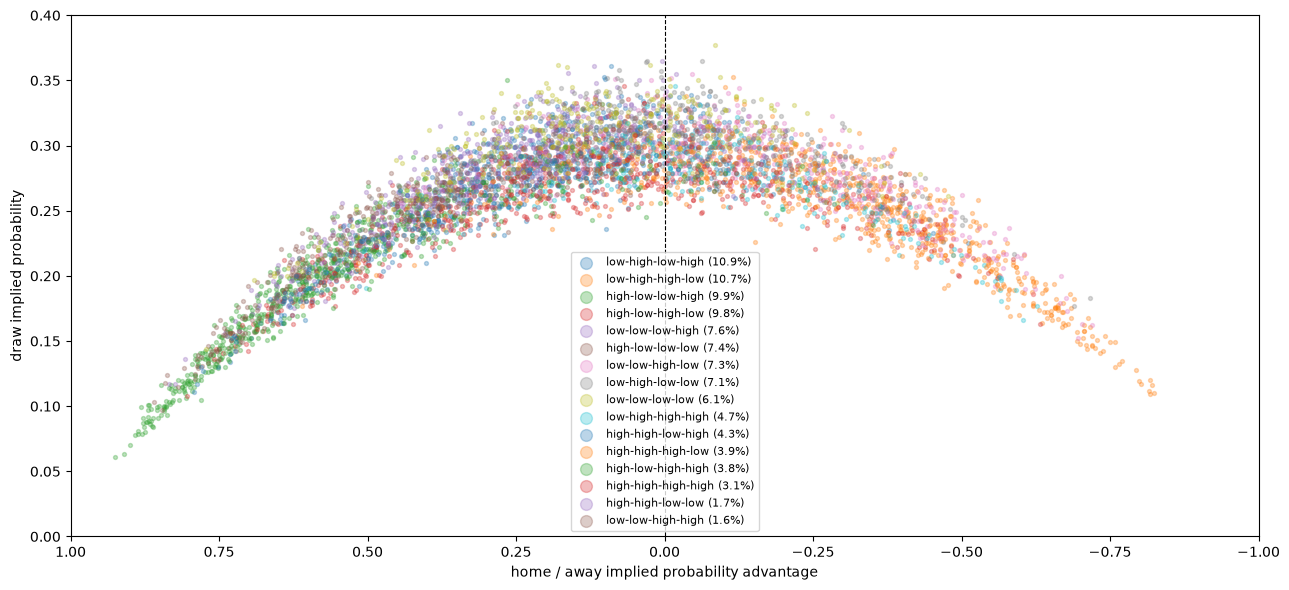

 606 low-high-low-high    H: 43.2% ( -5.6%)  D: 30.5% ( +6.3%)  A: 26.2% (-14.2%)
 590 low-high-high-low    H: 21.2% ( -9.3%)  D: 23.2% ( -7.6%)  A: 55.6% ( -1.8%)
 549 high-low-low-high    H: 71.8% ( +0.1%)  D: 16.4% (-17.1%)  A: 11.8% (-12.8%)
 541 high-low-high-low    H: 49.5% ( +6.4%)  D: 20.1% (-22.8%)  A: 30.3% ( -6.5%)
 419 low-low-low-high     H: 48.2% (-11.5%)  D: 30.1% ( +9.6%)  A: 21.7% ( -6.4%)
 412 high-low-low-low     H: 60.7% ( -4.0%)  D: 22.8% ( -3.4%)  A: 16.5% (-10.1%)
 404 low-low-high-low     H: 29.0% ( -4.2%)  D: 24.8% (-11.0%)  A: 46.3% ( -1.8%)
 394 low-high-low-low     H: 33.8% ( -6.7%)  D: 28.9% ( -3.8%)  A: 37.3% ( -4.0%)
 338 low-low-low-low      H: 36.4% (-17.8%)  D: 29.3% ( -2.8%)  A: 34.3% (+11.6%)
 262 low-high-high-high   H: 25.6% (-25.8%)  D: 26.7% ( -1.0%)  A: 47.7% (+10.1%)
 240 high-high-low-high   H: 51.2% (-14.0%)  D: 29.2% (+23.6%)  A: 19.6% ( -9.6%)
 215 high-high-high-low   H: 35.3% ( +6.4%)  D: 21.4% (-15.3%)  A: 43.3% ( -6.5%)
 212 high-low-hi

In [45]:
sub = abt[abt['homet_game_number'] > 8].copy()

sub['mrkt_home_away_impl_diff'] = sub['mrkt_home_impl'] - sub['mrkt_away_impl']

#query = "homet_season_goals_for_cat2m == 'low' and awayt_season_goals_for_cat2m == 'low'"
#sub = sub.query(query)

sub['matchup_cat'] = (sub['homet_season_shots_on_target_for_cat2m'] + '-' + 
                      sub['homet_season_shots_on_target_agst_cat2m'] + '-' +
                      sub['awayt_season_shots_on_target_for_cat2m'] + '-' + 
                      sub['awayt_season_shots_on_target_agst_cat2m'])

plot_impl_groups(sub, 'matchup_cat')